# Rhea_SolverDiagnose

Python Scripts for Geodynamics pre- and post- processing

---

**Authors:**
Ji-Ching Chen
Mike Gurnis

(c) California Institute of Technology 2026

Free for non-commercial academic use ONLY.
This program is distributed WITHOUT ANY WARRANTY whatsoever.

Copyright September 2026, by the California Institute of Technology.

---

Diagnose Rhea Newton solver nonlinear and linear (KSP) residual convergence from solver log files.

In [1]:
import os, sys, math
import re
import glob
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
PATH_LOG = '/Users/gurnis/Desktop/Gurnis_Files/Working/Current_Work/Rhea/Rhea_Models/'

def nonlinear_residual(model, logpath=PATH_LOG):
    print(logpath + model + "/output.txt")
    logfile = glob.glob(logpath + model + "/output.txt")[0]
    pat = re.compile(
        r"rhea_newton_solve_status newton_iter=(\d+), residual_norm=([0-9.eE+-]+),"
    )
    iters, residuals = [], []
    with open(logfile, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            m = pat.search(line)
            if m and 'components' not in line:
                iters.append(int(m.group(1)))
                residuals.append(float(m.group(2)))
    return iters, residuals

In [3]:
def linear_residual(model, logpath=PATH_LOG):
    logfile = glob.glob(logpath + model + "/output.txt")[0]
    pat_ksp  = re.compile(r"^\s*(\d+)\s+KSP Residual norm\s+([0-9.eE+-]+)")
    pat_done = re.compile(r"rhea_newton_solve_linear_solve_status newton_iter=(\d+),")

    linear, block = {}, []
    with open(logfile, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            m = pat_ksp.search(line)
            if m:
                block.append((int(m.group(1)), float(m.group(2))))
                continue
            m = pat_done.search(line)
            if m:
                newton_iter = int(m.group(1))
                linear[newton_iter] = np.array(block)
                block.clear()
    return linear

In [4]:
labelsize=15
bwith=3
colors = ['#282130','#849DAB','#CD5C5C','#35838D',
          '#97795D','#414F67','#4198B9','#2F4F4F']

## Models

/Users/gurnis/Desktop/Gurnis_Files/Working/Current_Work/Rhea/Rhea_Models/SB01/output.txt
/Users/gurnis/Desktop/Gurnis_Files/Working/Current_Work/Rhea/Rhea_Models/SB11/output.txt


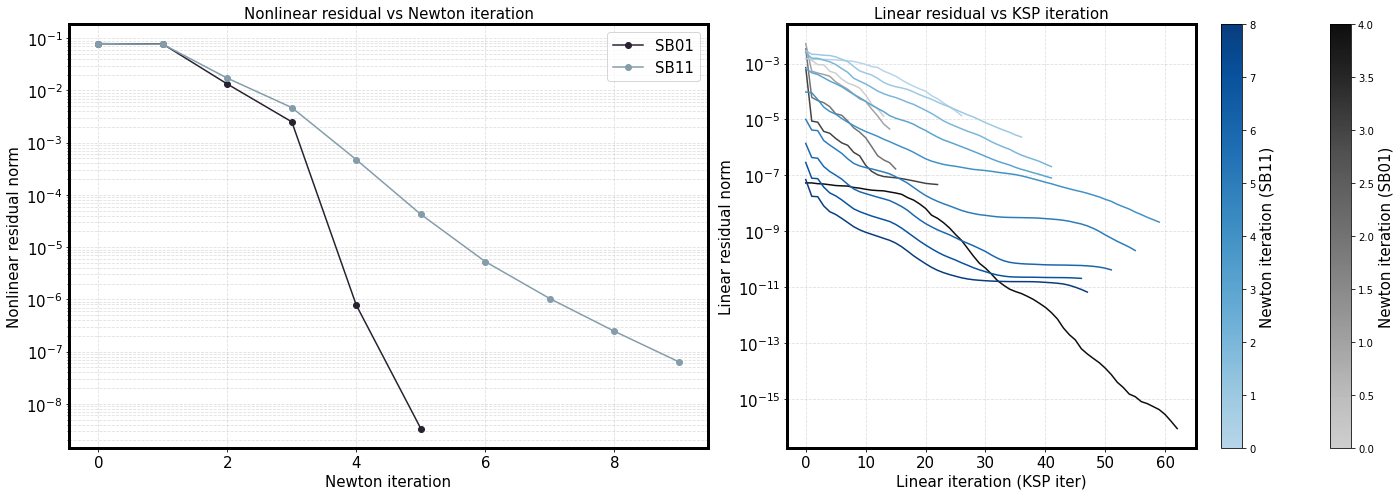

In [5]:
models = ['SB01', 'SB11']
iter_gap = 1
cmaps = ['Greys', 'Blues', 'Reds', 'Greens', 'Purples', 'Oranges']

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(20,7))

for i, model in enumerate(models):
    nl_iter, nl_residual = nonlinear_residual(model)
    ax3.semilogy(nl_iter, nl_residual, marker="o", color=colors[i % len(colors)], label=model)

    linear = linear_residual(model)
    iters = sorted(linear.keys())
    norm = mcolors.Normalize(vmin=min(iters), vmax=max(iters))
    base = cm.get_cmap(cmaps[i % len(cmaps)])
    cmap = mcolors.LinearSegmentedColormap.from_list("trunc", base(np.linspace(0.3,0.95,256)))
    for newton_iter, data in linear.items():
        linear_it, lin_residual = data.T
        color = cmap(norm(newton_iter))
        if newton_iter % iter_gap == 0:
            ax4.semilogy(linear_it, lin_residual, color=color, label=model)

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax4)
    cbar.set_label(f"Newton iteration ({model})", fontsize=labelsize)

ax3.set_xlabel("Newton iteration",fontsize=labelsize)
ax3.set_ylabel("Nonlinear residual norm",fontsize=labelsize)
ax3.set_title("Nonlinear residual vs Newton iteration",fontsize=labelsize)
ax3.grid(True, which="both", ls="--", alpha=0.4)
ax3.legend(fontsize=labelsize)
ax3.tick_params(labelsize=labelsize)
for axis in ['top','bottom','left','right']:
    ax3.spines[axis].set_linewidth(bwith)

ax4.set_xlabel("Linear iteration (KSP iter)", fontsize=labelsize)
ax4.set_ylabel("Linear residual norm", fontsize=labelsize)
ax4.set_title("Linear residual vs KSP iteration", fontsize=labelsize)
ax4.grid(True, which="both", ls="--", alpha=0.4)
ax4.tick_params(labelsize=labelsize)
for axis in ['top','bottom','left','right']:
    ax4.spines[axis].set_linewidth(bwith)

fig.tight_layout()
pdf_name = "residual_diagnostics_" + "_".join(models) + ".pdf"
fig.savefig(os.path.join(PATH_LOG, pdf_name), bbox_inches="tight")